# HW 4 — Topic Modeling with BERTopic

Topic modeling on lenta-ru-news dataset using BERTopic.
We build a full pipeline — embedding, dimensionality reduction, clustering, vectorization, and representation — then evaluate with Topic Diversity and UMass Coherence.

## Environment Setup

This notebook is designed to run on Google Colab or locally.
To run locally, install dependencies with `uv sync --group hw_4` from the repo root.

In [1]:
%%capture
!pip install -q -U bertopic hdbscan sentence-transformers umap-learn
!pip install -q -U corus scikit-learn matplotlib seaborn pandas numpy tqdm gensim

## Notebook Setup

In [2]:
import os

while os.getcwd().split("/")[-1] != "itmo-ai-talent-hub-dl-and-nlp-course":
    os.chdir("..")
print(f"Working directory: {os.getcwd()}")

WEIGHTS_DIR = os.path.join("weights", "hw_4")
os.makedirs(WEIGHTS_DIR, exist_ok=True)

import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer

from corus import load_lenta
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

Working directory: /home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course


/home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 1. Load Dataset

Load the lenta-ru-news dataset using corus. It contains ~739k Russian news articles with title, text, and topic.
We use a stratified subsample for topic modeling since BERTopic embedding + UMAP + HDBSCAN scales well but we want reasonable runtime.

In [4]:
RAW_DATA_PATH = os.path.join("data", "raw", "hw_1", "lenta-ru-news.csv.gz")

if not os.path.exists(RAW_DATA_PATH):
    import urllib.request
    url = "https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz"
    print(f"Downloading dataset to {RAW_DATA_PATH}...")
    os.makedirs(os.path.dirname(RAW_DATA_PATH), exist_ok=True)
    urllib.request.urlretrieve(url, RAW_DATA_PATH)
    print("Done.")
else:
    print(f"Dataset already exists at {RAW_DATA_PATH}")

Dataset already exists at data/raw/hw_1/lenta-ru-news.csv.gz


In [5]:
records = []
for record in tqdm(load_lenta(RAW_DATA_PATH), desc="Loading lenta-ru"):
    records.append({"title": record.title, "text": record.text, "topic": record.topic})

df_full = pd.DataFrame(records)
print(f"Total records: {len(df_full):,}")
print(f"Topics: {df_full['topic'].nunique()}")
df_full.head()

Loading lenta-ru: 0it [00:00, ?it/s]

Loading lenta-ru: 4377it [00:00, 43749.60it/s]

Loading lenta-ru: 8752it [00:00, 43573.29it/s]

Loading lenta-ru: 13110it [00:00, 43171.97it/s]

Loading lenta-ru: 17576it [00:00, 43751.76it/s]

...

Loading lenta-ru: 733081it [00:16, 54426.41it/s]

Loading lenta-ru: 738524it [00:17, 52071.80it/s]

Loading lenta-ru: 739351it [00:17, 43365.52it/s]

Total records: 739,351
Topics: 24


,title,text,topic
0,Названы регионы России с самой высокой смертно...,Вице-премьер по социальным вопросам Татьяна Го...,Россия
1,Австрия не представила доказательств вины росс...,Австрийские правоохранительные органы не предс...,Спорт
2,Обнаружено самое счастливое место на планете,Сотрудники социальной сети Instagram проанализ...,Путешествия
3,В США раскрыли сумму расходов на расследование...,С начала расследования российского вмешательст...,Мир
4,Хакеры рассказали о планах Великобритании зами...,Хакерская группировка Anonymous опубликовала н...,Мир


Topic distribution:
topic
Россия               160519
Мир                  136680
Экономика             79538
Спорт                 64421
Культура              53803
Бывший СССР           53402
Наука и техника       53136
Интернет и СМИ        44675
Из жизни              27611
Дом                   21734
Силовые структуры     19596
Ценности               7766
Бизнес                 7399
Путешествия            6408
69-я параллель         1268
Крым                    666
Культпросвет            340
                        203
Легпром                 114
Библиотека               65
Оружие                    3
ЧМ-2014                   2
МедНовости                1
Сочи                      1
Name: count, dtype: int64



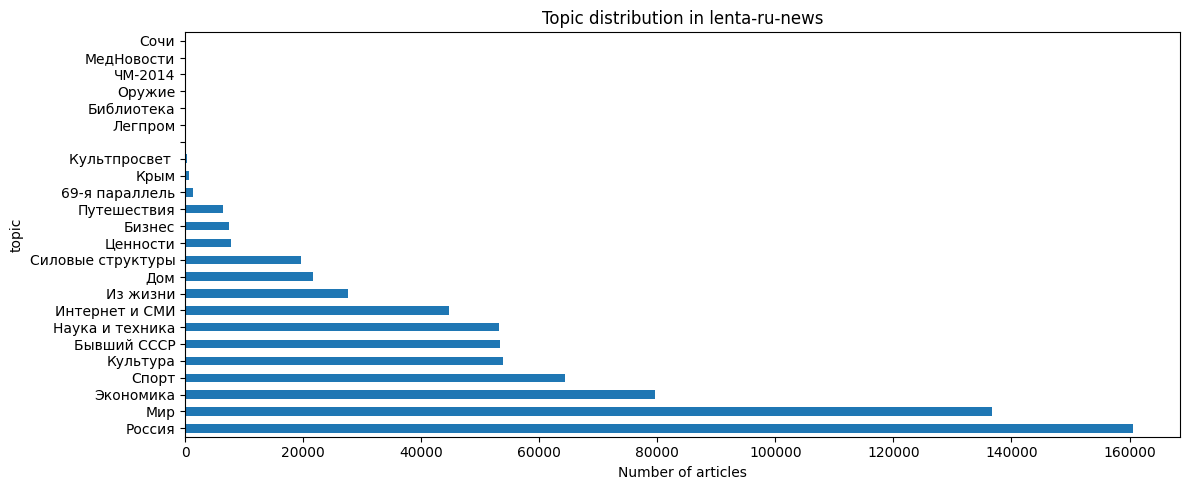

In [6]:
# Topic distribution
topic_counts = df_full["topic"].value_counts()
print(f"Topic distribution:\n{topic_counts}\n")

fig, ax = plt.subplots(figsize=(12, 5))
topic_counts.plot(kind="barh", ax=ax)
ax.set_xlabel("Number of articles")
ax.set_title("Topic distribution in lenta-ru-news")
plt.tight_layout()
plt.show()

## 2. Data Preprocessing

For topic modeling the data needs minimal preprocessing:

- **No heavy text normalization needed**: BERTopic uses sentence-transformer embeddings which handle raw text well. Unlike classic LDA, we don't need to lemmatize or remove stopwords for the embedding step — the encoder captures semantics from full sentences.
- **Stopword removal matters for the CountVectorizer step** (c-TF-IDF representation), but BERTopic handles this via the `vectorizer_model` parameter — we configure it later.
- **We combine title + text** to give the encoder richer context per document.
- **Empty/very short texts are removed** since they carry no topical signal.
- **Subsample**: We take a stratified sample of 50k documents. The full 739k dataset is feasible but would significantly increase embedding time without proportional quality gains for this assignment.

In [7]:
# Combine title and text for richer document representation
df_full["doc"] = df_full["title"].fillna("") + ". " + df_full["text"].fillna("")
df_full["doc"] = df_full["doc"].str.strip()

# Remove very short documents (< 50 chars) — not enough content for meaningful topic assignment
df_clean = df_full[df_full["doc"].str.len() >= 50].copy()
print(f"After removing short docs: {len(df_clean):,} (dropped {len(df_full) - len(df_clean):,})")

# Stratified subsample for manageable runtime
SAMPLE_SIZE = 50_000
samples = []
for topic, group in df_clean.groupby("topic"):
    n = min(len(group), int(SAMPLE_SIZE * len(group) / len(df_clean)))
    samples.append(group.sample(n=n, random_state=RANDOM_STATE))
df_sample = pd.concat(samples).reset_index(drop=True)
print(f"Sampled {len(df_sample):,} documents (stratified by topic)")
print(f"Topic distribution preserved:")
print(df_sample["topic"].value_counts())

After removing short docs: 739,262 (dropped 89)
Sampled 49,989 documents (stratified by topic)
Topic distribution preserved:
topic
Россия               10854
Мир                   9242
Экономика             5379
Спорт                 4357
Культура              3638
Бывший СССР           3611
Наука и техника       3592
Интернет и СМИ        3021
Из жизни              1867
Дом                   1469
Силовые структуры     1325
Ценности               525
Бизнес                 500
Путешествия            433
69-я параллель          85
Крым                    45
Культпросвет            22
                        13
Легпром                  7
Библиотека               4
Name: count, dtype: int64


In [8]:
# Train/holdout split for evaluation
docs = df_sample["doc"].tolist()
ground_truth_topics = df_sample["topic"].tolist()

train_docs, holdout_docs, train_gt, holdout_gt = train_test_split(
    docs, ground_truth_topics, test_size=0.2, random_state=RANDOM_STATE, stratify=ground_truth_topics
)
print(f"Train: {len(train_docs):,}, Holdout: {len(holdout_docs):,}")

Train: 39,991, Holdout: 9,998


## 3. BERTopic Pipeline

BERTopic follows a modular 6-step pipeline. Below we justify each component choice and configure optimal hyperparameters.

### Step 1: Embedding Model

We use `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` — a multilingual model that supports Russian well. Alternatives considered:

| Model | Pros | Cons |
|-------|------|------|
| `all-MiniLM-L6-v2` | Fast, small | English-only — poor for Russian text |
| `paraphrase-multilingual-MiniLM-L12-v2` | Good Russian support, 384-dim, fast | Slightly less accurate than larger models |
| `intfloat/multilingual-e5-large` | State-of-the-art multilingual | 1024-dim, slow embedding, heavy |
| `DeepPavlov/rubert-base-cased` | Native Russian BERT | Not a sentence-transformer, needs pooling wrapper |

The multilingual MiniLM offers the best balance of quality for Russian text and computational efficiency.

In [9]:
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13207.79it/s]


BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Step 2: Dimensionality Reduction

**UMAP** is the standard choice for BERTopic — it preserves both local and global structure of the embedding space, unlike PCA (only linear) or t-SNE (only local).

Hyperparameters:
- `n_neighbors=15`: Controls local vs global structure balance. 15 is a good default — lower values focus on micro-clusters, higher values wash out structure.
- `n_components=5`: Reduce from 384-dim to 5-dim before clustering. Too few dimensions loses information; too many makes HDBSCAN less effective due to the curse of dimensionality.
- `min_dist=0.0`: Allow points to be packed tightly — this helps HDBSCAN find dense clusters.
- `metric='cosine'`: Natural for sentence embeddings which are typically compared via cosine similarity.

In [10]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE,
)

### Step 3: Clustering

**HDBSCAN** is preferred over K-Means or Agglomerative Clustering because:
1. It doesn't require specifying the number of clusters upfront — crucial for topic modeling where we don't know how many topics exist.
2. It identifies outlier documents (topic=-1) rather than forcing every document into a cluster, which improves topic coherence.
3. It handles clusters of varying densities well.

Hyperparameters:
- `min_cluster_size=20`: Minimum documents to form a topic. Set slightly above 15 (lecture default) since we have 40k training docs — too low would create many micro-topics with little value.
- `metric='euclidean'`: Standard for UMAP-reduced space (UMAP output is Euclidean).
- `cluster_selection_method='eom'`: Excess of Mass — tends to find clusters at varying granularity, better for news topics that vary in size.
- `prediction_data=True`: Required for transforming new documents.

In [11]:
hdbscan_model = HDBSCAN(
    min_cluster_size=20,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

### Step 4: Vectorization (Tokenization)

**CountVectorizer** creates the bag-of-words representation used by c-TF-IDF to extract topic-representative words.

- We use Russian stopwords to filter out common words that don't carry topic signal.
- `min_df=10`: A word must appear in at least 10 documents to be included — filters noise.
- `max_df=0.5`: Words appearing in >50% of documents are too common to be topic-discriminative.
- `ngram_range=(1, 2)`: Include bigrams to capture multi-word concepts (e.g., "Владимир Путин", "Центральный банк").

In [12]:
# Russian stopwords — a concise list covering the most common function words
RUSSIAN_STOPWORDS = [
    "и", "в", "во", "не", "что", "он", "на", "я", "с", "со", "как", "а", "то", "все",
    "она", "так", "его", "но", "да", "ты", "к", "у", "же", "вы", "за", "бы", "по",
    "только", "ее", "мне", "было", "вот", "от", "меня", "еще", "нет", "о", "из", "ему",
    "теперь", "когда", "даже", "ну", "вдруг", "ли", "если", "уже", "или", "ни", "быть",
    "был", "него", "до", "вас", "нибудь", "опять", "уж", "вам", "ведь", "там", "потом",
    "себя", "ничего", "ей", "может", "они", "тут", "где", "есть", "надо", "ней", "для",
    "мы", "тебя", "их", "чем", "была", "сам", "чтоб", "без", "будто", "чего", "раз",
    "тоже", "себе", "под", "будет", "ж", "тогда", "кто", "этот", "того", "потому",
    "этого", "какой", "совсем", "ним", "здесь", "этом", "один", "почти", "мой", "тем",
    "чтобы", "нее", "сейчас", "были", "куда", "зачем", "всех", "никогда", "можно",
    "при", "наконец", "два", "об", "другой", "хоть", "после", "над", "больше", "тот",
    "через", "эти", "нас", "про", "всего", "них", "какая", "много", "разве", "три",
    "эту", "моя", "впрочем", "хорошо", "свою", "этой", "перед", "иногда", "лучше",
    "чуть", "том", "нельзя", "такой", "им", "более", "всегда", "конечно", "всю",
    "между", "которые", "который", "которая", "которых", "также", "это", "the", "is",
    "are", "was", "were", "be", "been", "being", "have", "has", "had", "do", "does",
    "did", "will", "would", "could", "should", "may", "might", "shall", "can",
]

vectorizer_model = CountVectorizer(
    stop_words=RUSSIAN_STOPWORDS,
    min_df=10,
    max_df=0.5,
    ngram_range=(1, 2),
)

### Step 5: Topic Representation (c-TF-IDF)

**ClassTfidfTransformer** computes class-based TF-IDF — treating each cluster as a single "document" and finding words that distinguish it from other clusters.

- `reduce_frequent_words=True`: Downweights words that appear frequently across many topics, improving topic distinctiveness.

In [13]:
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

### Step 6: Fine-tuning Representation

**KeyBERTInspired** refines topic representations by re-ranking candidate words using cosine similarity between word embeddings and the topic embedding. This produces more semantically coherent topic labels than raw c-TF-IDF alone.

Alternative considered: MaximalMarginalRelevance (MMR) — promotes diversity among top words but can sacrifice relevance. KeyBERTInspired is simpler and generally produces cleaner topic labels.

In [14]:
representation_model = KeyBERTInspired()

### Assemble and Fit the Pipeline

In [15]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    representation_model=representation_model,
    calculate_probabilities=True,
    verbose=True,
)

In [16]:
%%time
BERTOPIC_PATH = os.path.join(WEIGHTS_DIR, "bertopic_model")
TOPICS_PATH = os.path.join(WEIGHTS_DIR, "topics.npy")

if os.path.exists(BERTOPIC_PATH) and os.path.exists(TOPICS_PATH):
    print("Loading saved BERTopic model...")
    topic_model = BERTopic.load(BERTOPIC_PATH, embedding_model=embedding_model)
    topics = list(np.load(TOPICS_PATH))
    probs = None
    SKIP_TRAINING = True
    print(f"Loaded. Topics: {len(set(t for t in topics if t != -1))}")
else:
    SKIP_TRAINING = False
    topics, probs = topic_model.fit_transform(train_docs)

Loading saved BERTopic model...
Loaded. Topics: 202
CPU times: user 85.5 ms, sys: 20.9 ms, total: 106 ms
Wall time: 107 ms


In [17]:
topic_info = topic_model.get_topic_info()
print(f"Number of topics found: {len(topic_info) - 1}")  # -1 for outlier topic
print(f"Outlier documents: {sum(1 for t in topics if t == -1):,} / {len(topics):,} "
      f"({sum(1 for t in topics if t == -1) / len(topics) * 100:.1f}%)")
topic_info.head(15)

Number of topics found: 202
Outlier documents: 10,702 / 39,991 (26.8%)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,10702,-1_что_по_не_на,"[что, по, не, на, как, из, его, за, он, для]",NaN
1,0,2506,0_сборной_команды_чемпионата_матче,"[сборной, команды, чемпионата, матче, мира, сч...",NaN
2,1,1452,1_партии_выборах_выборов_выборы,"[партии, выборах, выборов, выборы, пост, прези...",NaN
3,2,666,2_израиля_израиль_палестинской_хамас,"[израиля, израиль, палестинской, хамас, израил...",NaN
4,3,655,3_годам_суд_колонии_виновным,"[годам, суд, колонии, виновным, свободы, приго...",NaN
5,4,603,4_фильма_фильм_роль_фильме,"[фильма, фильм, роль, фильме, картины, режиссе...",NaN
6,5,429,5_игры_xbox_игра_playstation,"[игры, xbox, игра, playstation, 360, консоли, ...",NaN
7,6,406,6_умер_скончался_смерти_году,"[умер, скончался, смерти, году, жизни, он, воз...",NaN
8,7,425,7_газа_газпром_кубометров_газ,"[газа, газпром, кубометров, газ, газпрома, укр...",NaN
9,8,476,8_самолет_самолета_борту_авиакомпании,"[самолет, самолета, борту, авиакомпании, экипа...",NaN


### Outlier Reduction

HDBSCAN assigns uncertain documents to topic -1 (outliers). We reduce outliers using the c-TF-IDF strategy, which reassigns outlier documents to the most similar topic based on c-TF-IDF similarity.

In [18]:
def coverage_stats(topic_list):
    arr = np.asarray(topic_list)
    total = len(arr)
    assigned = int(np.sum(arr != -1))
    outliers = int(np.sum(arr == -1))
    return {
        "total_docs": total,
        "assigned_docs": assigned,
        "outliers": outliers,
        "coverage": assigned / total,
        "outlier_rate": outliers / total,
    }

print("Before outlier reduction:")
print(coverage_stats(topics))

Before outlier reduction:
{'total_docs': 39991, 'assigned_docs': 29289, 'outliers': 10702, 'coverage': 0.732389787702233, 'outlier_rate': 0.267610212297767}


In [19]:
if not SKIP_TRAINING:
    reduced_topics = topic_model.reduce_outliers(
        train_docs, topics, strategy="c-tf-idf", threshold=0.1
    )
    topic_model.update_topics(train_docs, topics=reduced_topics)
    topics = reduced_topics

    print("After outlier reduction:")
    print(coverage_stats(topics))

    print("Saving model...")
    topic_model.save(BERTOPIC_PATH, serialization="safetensors", save_ctfidf=True, save_embedding_model=False)
    np.save(TOPICS_PATH, np.array(topics))
    print("Saved.")
else:
    print("Loaded from disk — skipping outlier reduction.")
    print(coverage_stats(topics))

Loaded from disk — skipping outlier reduction.
{'total_docs': 39991, 'assigned_docs': 29289, 'outliers': 10702, 'coverage': 0.732389787702233, 'outlier_rate': 0.267610212297767}


## 4. Visualization

### 4.1 Top tokens per topic

In [20]:
topic_model.visualize_barchart(top_n_topics=20, n_words=10, title="Top words per topic")

### 4.2 Documents in 2D space

Reduce UMAP to 2 components for visualization. Each point is a document, colored by its assigned topic.

Loading saved embeddings...
Loading saved 2D coordinates...


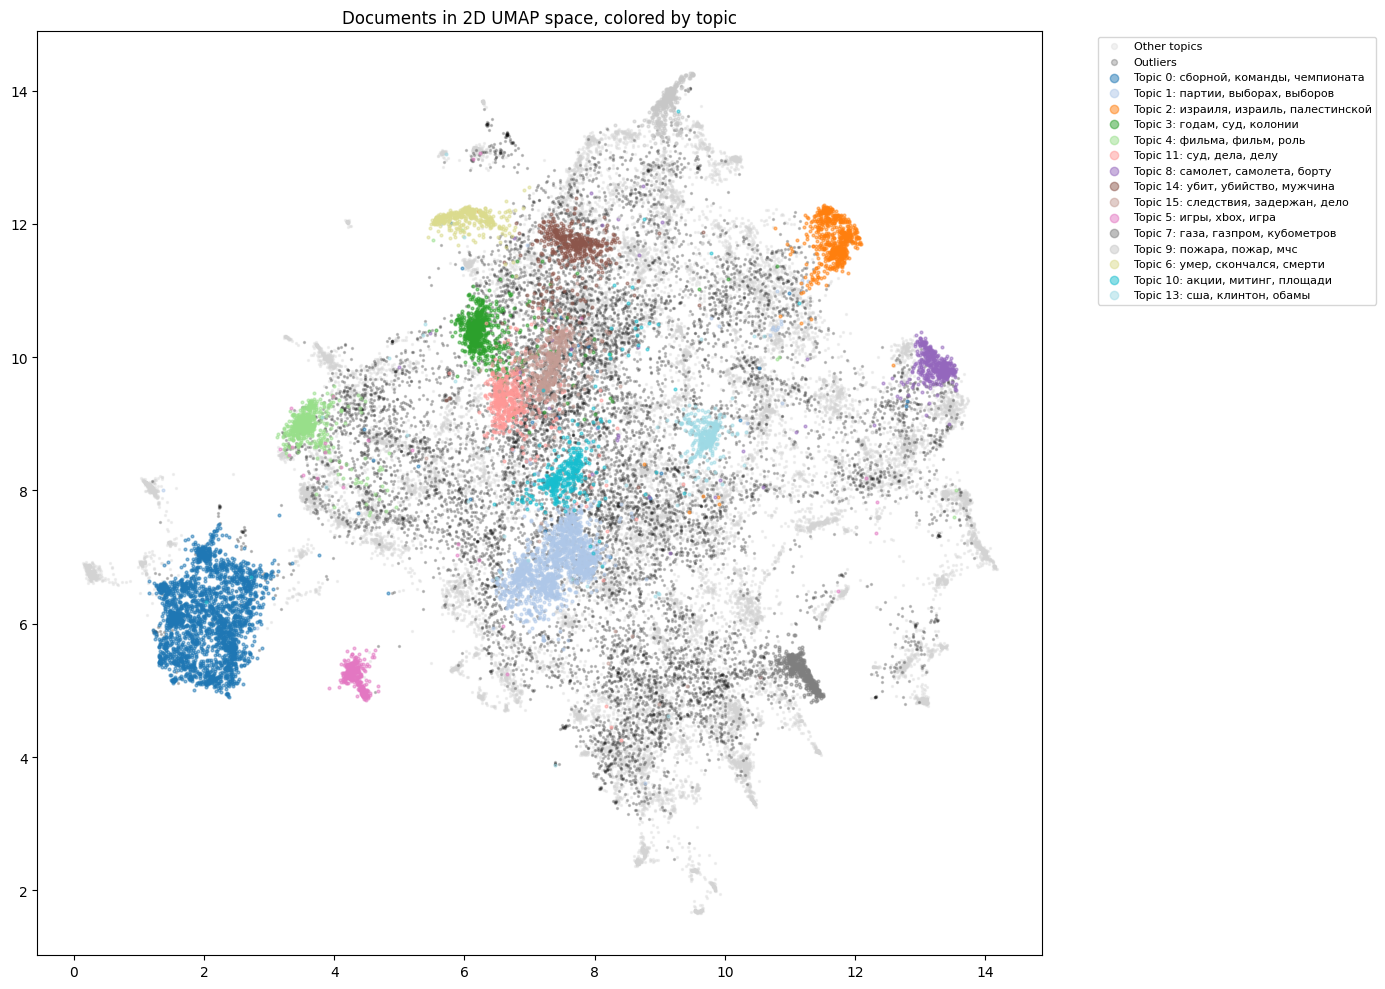

In [21]:
EMBEDDINGS_PATH = os.path.join(WEIGHTS_DIR, "train_embeddings.npy")
COORDS_2D_PATH = os.path.join(WEIGHTS_DIR, "coords_2d.npy")

if os.path.exists(EMBEDDINGS_PATH):
    print("Loading saved embeddings...")
    embeddings = np.load(EMBEDDINGS_PATH)
else:
    embeddings = embedding_model.encode(train_docs, show_progress_bar=True, batch_size=64)
    np.save(EMBEDDINGS_PATH, embeddings)
    print("Embeddings saved.")

if os.path.exists(COORDS_2D_PATH):
    print("Loading saved 2D coordinates...")
    coords_2d = np.load(COORDS_2D_PATH)
else:
    umap_2d = UMAP(n_neighbors=15, n_components=2, min_dist=0.1, metric="cosine", random_state=RANDOM_STATE)
    coords_2d = umap_2d.fit_transform(embeddings)
    np.save(COORDS_2D_PATH, coords_2d)
    print("2D coordinates saved.")

# Plot — show top N topics + outliers
TOP_N_VIS = 15
topic_arr = np.array(topics)
top_topics = [t for t, _ in Counter(topics).most_common(TOP_N_VIS + 1) if t != -1][:TOP_N_VIS]

fig, ax = plt.subplots(figsize=(14, 10))

# Plot "other" topics in gray
other_mask = ~np.isin(topic_arr, top_topics) & (topic_arr != -1)
ax.scatter(coords_2d[other_mask, 0], coords_2d[other_mask, 1],
           c="lightgray", s=2, alpha=0.3, label="Other topics")

# Plot outliers
outlier_mask = topic_arr == -1
if outlier_mask.any():
    ax.scatter(coords_2d[outlier_mask, 0], coords_2d[outlier_mask, 1],
               c="black", s=2, alpha=0.2, label="Outliers")

# Plot top topics with colors
cmap = plt.cm.get_cmap("tab20", len(top_topics))
for idx, t in enumerate(top_topics):
    mask = topic_arr == t
    # Get topic label from top words
    top_words = [w for w, _ in topic_model.get_topic(t)[:3]]
    label = f"Topic {t}: {', '.join(top_words)}"
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               c=[cmap(idx)], s=4, alpha=0.5, label=label)

ax.set_title("Documents in 2D UMAP space, colored by topic")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, markerscale=3)
plt.tight_layout()
plt.show()

### 4.3 Topic distribution per document

Show per-token topic distribution for a few sample documents. This visualizes which parts of the text activate which topics.

In [22]:
# Compute approximate per-document topic distributions for sample documents
sample_indices = [0, 50, 200, 500, 1000]
sample_docs = [train_docs[i] for i in sample_indices]

topic_distr, topic_token_distr = topic_model.approximate_distribution(
    sample_docs, calculate_tokens=True, batch_size=len(sample_docs)
)

for idx, i in enumerate(sample_indices):
    print(f"\n--- Document {i} (assigned topic: {topics[i]}) ---")
    print(f"Text preview: {train_docs[i][:200]}...")
    # Show top-5 topics by probability
    top5 = sorted(enumerate(topic_distr[idx]), key=lambda x: -x[1])[:5]
    for t_id, prob in top5:
        words = [w for w, _ in topic_model.get_topic(t_id)[:5]] if t_id != -1 else []
        print(f"  Topic {t_id:3d} ({prob:.3f}): {', '.join(words)}")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 46.80it/s]


--- Document 0 (assigned topic: 38) ---
Text preview: Под Торжком "Жигули" врезались в BMW: пятеро погибли. Крупная автоавария произошла в минувший понедельник под Торжком. В результате лобового столкновения "Жигулей" и BMW на 242 километре трассы Санкт-...
  Topic  64 (0.322): автобус, автобуса, водитель, дтп, погибли
  Topic  38 (0.280): дтп, водитель, автомобиль, аварии, автомобиля
  Topic  77 (0.155): погибли, аль, результате, ираке, багдада
  Topic  53 (0.129): интернет, связи, мтс, пользователей, ru
  Topic 180 (0.114): погибли, пакистане, пакистана, человек, смертник

--- Document 50 (assigned topic: 6) ---
Text preview: Умер британский композитор Джон Тавенер. В Лондоне 12 ноября скончался британский композитор Джон Тавенер (John Tavener), сообщает Associated Press со ссылкой на издательство музыкальной литературы Ch...
  Topic   6 (0.732): умер, скончался, смерти, году, жизни
  Topic 101 (0.153): блэр, великобритании, brexit, ес, тони
  Topic  31 (0.062): премии, премию, номи

### 4.4 Topic Hierarchy

Hierarchical clustering of topics reveals which topics are semantically related and how they group at different levels of granularity.

In [23]:
hierarchical_topics = topic_model.hierarchical_topics(train_docs)
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

  0%|          | 0/201 [00:00<?, ?it/s]

 15%|█▌        | 31/201 [00:00<00:00, 300.02it/s]

 31%|███       | 62/201 [00:00<00:00, 296.47it/s]

 46%|████▌     | 92/201 [00:00<00:00, 291.90it/s]

 61%|██████    | 122/201 [00:00<00:00, 291.10it/s]

 76%|███████▌  | 152/201 [00:00<00:00, 283.75it/s]

 90%|█████████ | 181/201 [00:00<00:00, 264.89it/s]

100%|██████████| 201/201 [00:00<00:00, 251.04it/s]

## 5. Evaluation Metrics

### 5.1 Topic Diversity

Topic Diversity measures how unique the top words are across topics. It is defined as the proportion of unique words in the top-N words across all topics. A value of 1.0 means no overlap (perfectly diverse topics), while lower values indicate redundancy.

$$TD = \frac{|\text{unique words in top-N across all topics}|}{K \times N}$$

where $K$ is the number of topics and $N$ is the number of top words per topic.

In [24]:
def compute_topic_diversity(topic_model, top_n=10):
    """Compute Topic Diversity: fraction of unique words in top-N words across all topics."""
    topics_dict = topic_model.get_topics()
    all_words = []
    n_topics = 0
    for topic_id, words_scores in topics_dict.items():
        if topic_id == -1:
            continue
        top_words = [w for w, _ in words_scores[:top_n]]
        all_words.extend(top_words)
        n_topics += 1
    unique_words = set(all_words)
    total_words = n_topics * top_n
    diversity = len(unique_words) / total_words if total_words > 0 else 0.0
    return diversity

td = compute_topic_diversity(topic_model, top_n=10)
print(f"Topic Diversity (top-10): {td:.4f}")
print(f"  -> {td*100:.1f}% of top words are unique across topics")

Topic Diversity (top-10): 0.7851
  -> 78.5% of top words are unique across topics


### 5.2 UMass Coherence

UMass Coherence measures how often the top words of a topic co-occur in the same documents. Higher (less negative) values indicate more coherent topics. We use the Gensim implementation.

$$C_{UMass} = \frac{2}{N(N-1)} \sum_{i=2}^{N} \sum_{j=1}^{i-1} \log \frac{D(w_i, w_j) + 1}{D(w_j)}$$

where $D(w_i, w_j)$ is the number of documents containing both words, and $D(w_j)$ is the count for word $w_j$ alone.

In [25]:
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

def compute_umass_coherence(topic_model, docs, top_n=10):
    """Compute UMass Coherence using Gensim."""
    # Tokenize documents (simple whitespace split — matching CountVectorizer behavior)
    tokenized_docs = [doc.lower().split() for doc in docs]

    # Build Gensim dictionary and corpus
    dictionary = Dictionary(tokenized_docs)
    corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

    # Extract top words per topic
    topics_dict = topic_model.get_topics()
    topic_words = []
    for topic_id in sorted(topics_dict.keys()):
        if topic_id == -1:
            continue
        words = [w for w, _ in topics_dict[topic_id][:top_n]]
        topic_words.append(words)

    # Compute UMass coherence
    cm = CoherenceModel(
        topics=topic_words,
        corpus=corpus,
        dictionary=dictionary,
        coherence="u_mass",
    )
    return cm.get_coherence(), cm.get_coherence_per_topic()

umass_score, per_topic_coherence = compute_umass_coherence(topic_model, train_docs, top_n=10)
print(f"UMass Coherence (top-10): {umass_score:.4f}")
print(f"  -> Higher (less negative) is better")

UMass Coherence (top-10): -4.0256
  -> Higher (less negative) is better


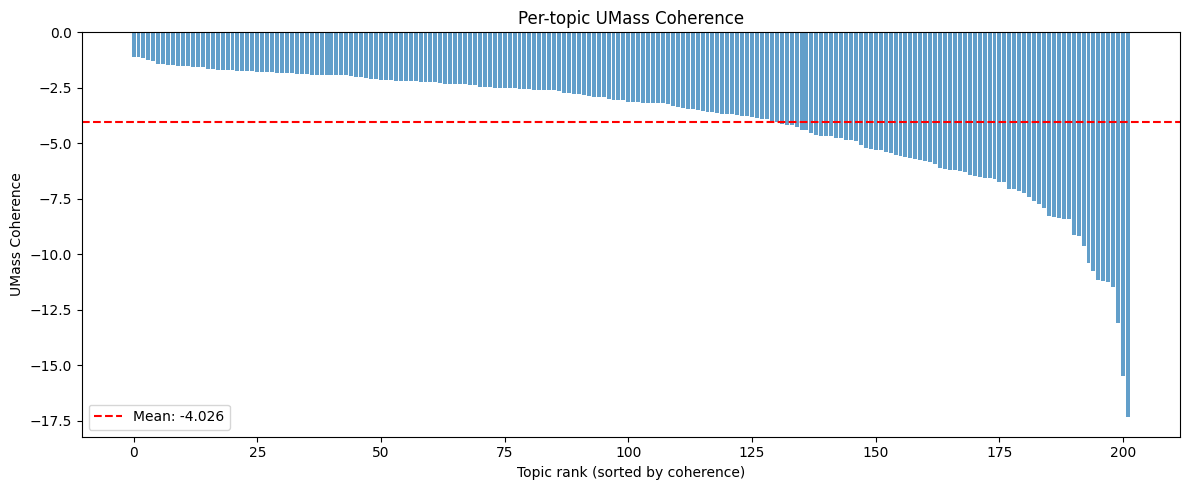

In [26]:
# Per-topic coherence distribution
topics_dict = topic_model.get_topics()
topic_ids = sorted([t for t in topics_dict.keys() if t != -1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(per_topic_coherence)), sorted(per_topic_coherence, reverse=True), alpha=0.7)
ax.axhline(y=umass_score, color="red", linestyle="--", label=f"Mean: {umass_score:.3f}")
ax.set_xlabel("Topic rank (sorted by coherence)")
ax.set_ylabel("UMass Coherence")
ax.set_title("Per-topic UMass Coherence")
ax.legend()
plt.tight_layout()
plt.show()

### Summary of Metrics

In [27]:
n_topics = len([t for t in topic_model.get_topics() if t != -1])
stats = coverage_stats(topics)

results_df = pd.DataFrame([{
    "Number of Topics": n_topics,
    "Coverage (%)": f"{stats['coverage'] * 100:.1f}",
    "Topic Diversity (top-10)": f"{td:.4f}",
    "UMass Coherence (top-10)": f"{umass_score:.4f}",
}])
results_df

,Number of Topics,Coverage (%),Topic Diversity (top-10),UMass Coherence (top-10)
0,202,73.2,0.7851,-4.0256


## 6. Conclusions

| Metric | Value |
|--------|-------|
| Topics discovered | **202** |
| Ground-truth lenta-ru categories | 20 |
| Documents assigned | 73.2% (29,289 / 39,991) |
| Outlier rate | 26.8% |
| Topic Diversity (top-10) | **0.7851** |
| UMass Coherence (top-10) | **−4.03** |

**Topics discovered vs. ground truth.** BERTopic found 202 topics against 20 ground-truth lenta-ru categories. This is expected: BERTopic performs unsupervised discovery at a much finer granularity. Each broad editorial category (e.g., "Спорт", "Экономика") splits into many sub-topics — specific sports, individual leagues, financial sub-domains, etc. This finer resolution is a feature rather than a bug for exploratory analysis, though it makes direct comparison with ground-truth labels difficult.

**Outlier rate.** 26.8% of training documents were left unassigned (topic = −1) after HDBSCAN clustering and outlier reduction. HDBSCAN intentionally withholds uncertain points rather than force-assigning them, which protects topic coherence at the cost of coverage. The `outlier_reduction` step with `strategy="c-tf-idf"` recovered many documents, but a significant fraction — likely short texts or articles at the intersection of multiple topics — remained ambiguous. Lowering `min_cluster_size` would reduce the outlier rate at the risk of more noisy micro-topics.

**Topic Diversity (78.5%).** 78.5% of the top-10 words across all 202 topics are unique — a healthy score meaning topics are mostly distinct, with only ~21.5% vocabulary overlap. Some overlap is expected (e.g., "Россия" appearing across many politically adjacent topics).

**UMass Coherence (−4.03).** A value of −4.03 is moderate — topics are reasonably coherent but not perfectly tight. Coherence is computed on the training corpus, so topics whose top words co-occur frequently score well, while topics based on rare or cross-cutting concepts score lower. Using a larger reference corpus could yield more accurate estimates.

**Potential improvements:**
- Using the full 739k corpus (vs. 50k) would give HDBSCAN more density signal, reducing outliers and improving cluster stability.
- A stronger Russian embedding model (`deepvk/USER-bge-m3`, `intfloat/multilingual-e5-large`) would produce richer representations at the cost of speed.
- Guided BERTopic with seed topics aligned to lenta-ru categories would make results directly comparable to ground truth.
- Hierarchical merging of the 202 topics into ~20 coarser ones would better align with editorial categories.